In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded=files.upload()

Saving flight_dataset.csv to flight_dataset.csv


In [ ]:
df=pd.read_csv('flight_dataset.csv')
df.head()

,flight_id,airline,origin,destination,flight_date,available_seats,ticket_price,status
0,FL1001,SpiceJet,Chennai,Mumbai,2026-02-09,192,10701,Delayed
1,FL1002,SpiceJet,Ahmedabad,Hyderabad,2026-03-27,168,10347,Delayed
2,FL1003,Akasa Air,Ahmedabad,Hyderabad,2026-03-20,132,12117,Delayed
3,FL1004,Vistara,Hyderabad,Chennai,2026-04-25,55,4332,Delayed
4,FL1005,Air India,Kolkata,Bengaluru,2026-05-22,199,5345,Cancelled


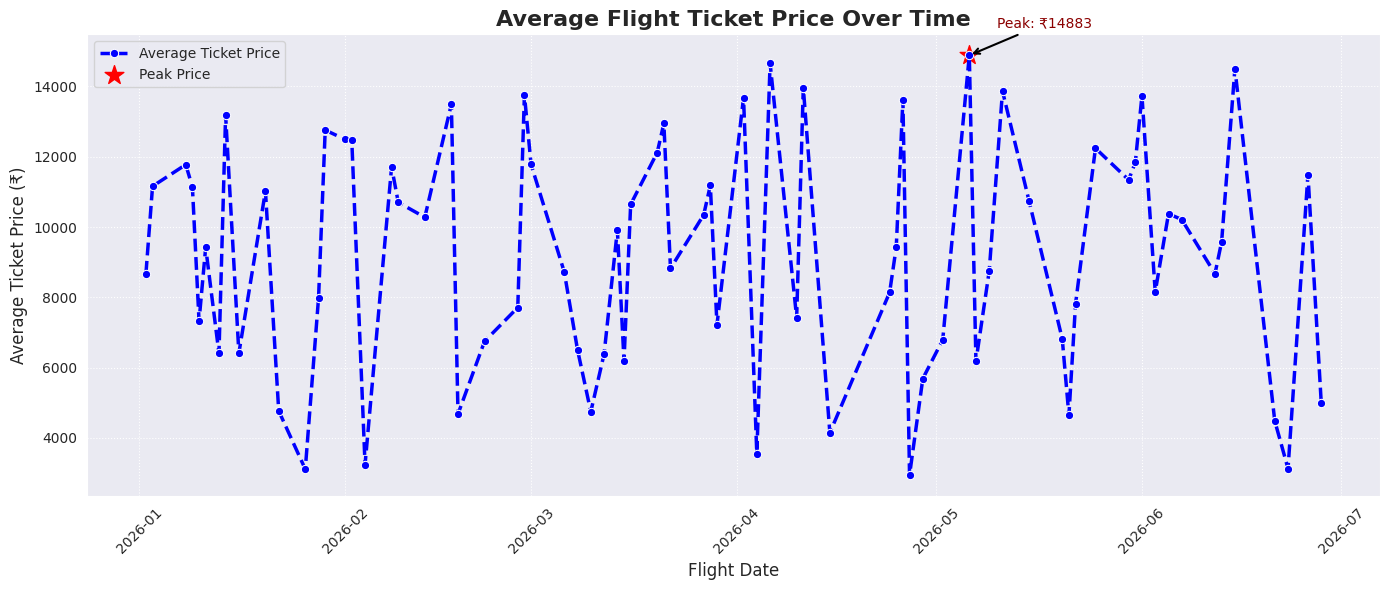

In [ ]:
df['flight_date'] = pd.to_datetime(df['flight_date'])

# Average ticket price by date
daily_price = df.groupby('flight_date')['ticket_price'].mean().reset_index()

# Find peak point
peak_idx = daily_price['ticket_price'].idxmax()
peak_date = daily_price.loc[peak_idx, 'flight_date']
peak_price = daily_price.loc[peak_idx, 'ticket_price']

# Seaborn style
sns.set_style("darkgrid")

plt.figure(figsize=(14, 6))

# Time series plot
sns.lineplot(
    data=daily_price,
    x='flight_date',
    y='ticket_price',
    color='blue',
    linestyle='--',
    linewidth=2.5,
    marker='o',
    label='Average Ticket Price'
)

# Highlight peak
plt.scatter(
    peak_date,
    peak_price,
    color='red',
    s=200,
    marker='*',
    label='Peak Price'
)

# Annotation
plt.annotate(
    f'Peak: ₹{peak_price:.0f}',
    xy=(peak_date, peak_price),
    xytext=(20, 20),
    textcoords='offset points',
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        lw=1.5
    ),
    fontsize=10,
    color='darkred'
)

# Labels and title
plt.title('Average Flight Ticket Price Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Flight Date', fontsize=12)
plt.ylabel('Average Ticket Price (₹)', fontsize=12)

# Legend
plt.legend()

# Grid
plt.grid(True, linestyle=':')

# Rotate dates
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
iris=sns.load_dataset('iris')
iris.info()
iris.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


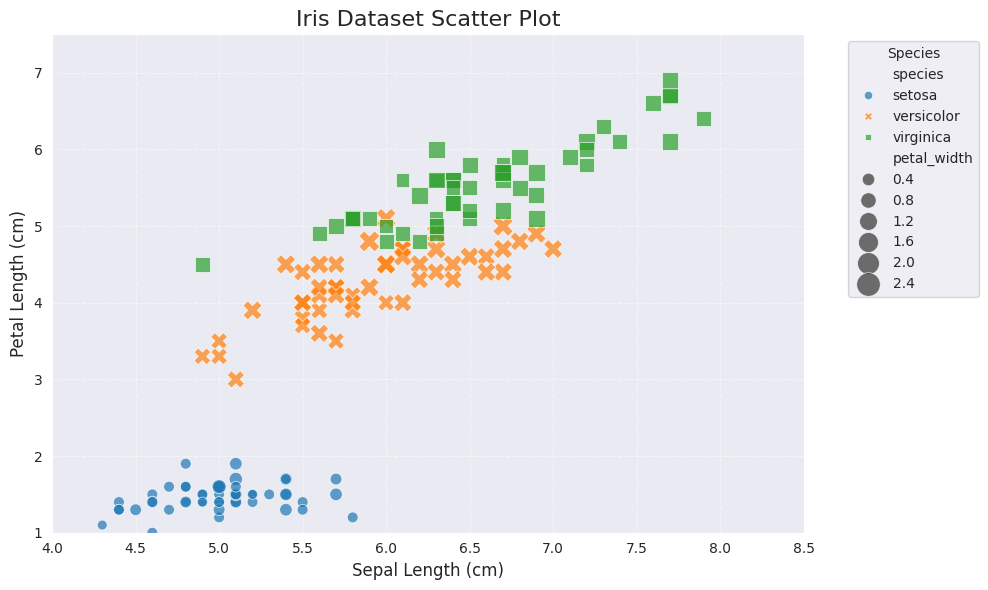

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=iris,
    x="sepal_length",
    y="petal_length",
    hue="species",          # Color by species
    style="species",        # Different marker per species
    size="petal_width",     # Point size varies
    sizes=(50, 300),        # Min and max size
    alpha=0.7               # Transparency
)

# Title and Labels
plt.title("Iris Dataset Scatter Plot", fontsize=16)
plt.xlabel("Sepal Length (cm)", fontsize=12)
plt.ylabel("Petal Length (cm)", fontsize=12)

# Axis Limits
plt.xlim(4, 8.5)
plt.ylim(1, 7.5)

# Legend
plt.legend(title="Species", bbox_to_anchor=(1.05, 1), loc="upper left")

# Grid
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
tips=sns.load_dataset('tips')
tips.info()
tips.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


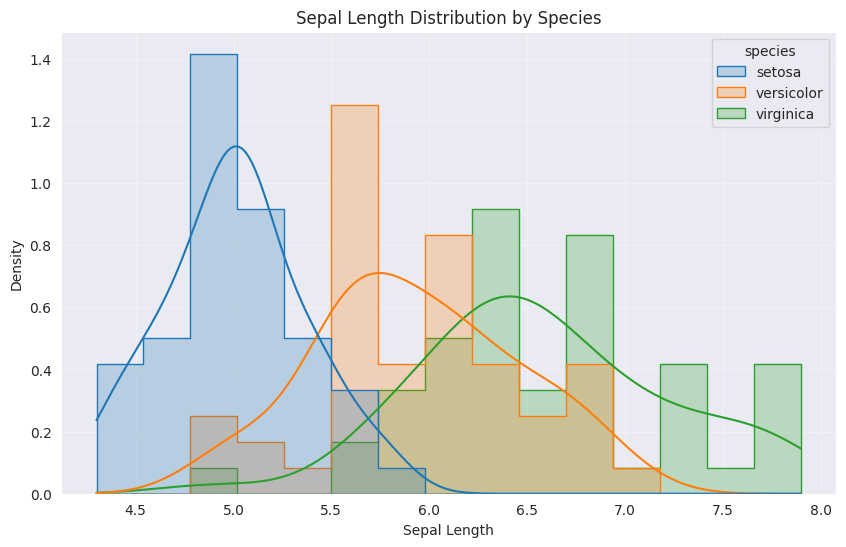

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

iris = sns.load_dataset("iris")

plt.figure(figsize=(10,6))

sns.histplot(
    data=iris,
    x='sepal_length',
    hue='species',
    bins=15,
    stat='density',
    kde=True,
    element='step',
    common_norm=False
)

plt.title('Sepal Length Distribution by Species')
plt.xlabel('Sepal Length')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)

plt.show()